# Ekstraksi Fitur Time Series Polutan Udara dengan TSFEL pada Data Polutan Kecamatan Tikala, Manado

Notebook ini merupakan kelanjutan dari notebook *Analisis Data Polutan Udara di Wilayah Kecamatan Tikala Kabupaten Manado*, yang sudah membahas Business Understanding dan Data Understanding termasuk proses pengambilan data dari Sentinel-5P. Fokus notebook ini adalah tahap ekstraksi fitur dari data CO, NO2, dan SO2 memakai pustaka TSFEL, dimulai dari `pollutant_data_tikala.csv` yang sudah dihasilkan sebelumnya.

TSFEL (Time Series Feature Extraction Library) membantu mengubah data deret waktu mensehingga kumpulan angka ringkas yang disebut fitur. Tiap fitur menangkap satu ciri khas dari sinyal, bisa berupa seberapa tinggi rata-ratanya, seberapa liar fluktuasinya, atau frekuensi mana yang paling menonjol di dalamnya.

Data mentah polutan tercatat sebagai ratusan nilai harian yang naik turun sepanjang tahun, sehingtidak repot kalau mau dibandingkan langsung antarwilayah. Lewat ekstraksi fitur, satu tahun pola data itu dipadatkan sehingga satu baris angka per wilayah, sehingga bisa diperlakukan sebagai data tabular biasa dan lebih siap digunakan untuk tahap analisis berikutnya seperti clustering.

TSFEL membagi 68 fitur yang tersedia ke dalam empat domain:
- **Statistical**, memelihat karakteristik distribusi nilai sinyal (mean, standar deviasi, skewness, dan sejenisnya), tanpa peduli urutan waktunya
- **Temporal**, memelihat pola perubahan sinyal sepanjang waktu (kemiringan tren, jumlah titik balik, dan lainnya)
- **Spectral**, mengubah sinyal ke domain frekuensi lewat FFT atau wavelet, baru diukur karakteristiknya di sana
- **Fractal**, mengukur kompleksitas dan pola "memori jangka panjang" pada sinyal

Ekstraksi pada notebook ini dilakukan terpisah untuk titidak polutan (CO, NO2, SO2), masing-masing menghasilkan 68 fitur.

## 1. Penjelasan Fitur Ekstraksi TSFEL

### 1.1 Deskripsi Singkat Seluruh 68 Fitur TSFEL

Sebagai referensi ringkas, berikut deskripsi singkat seluruh 68 fitur yang diekstraksi, dikelompokkan per domain. Dua fitur yang ditugaskan kepada penulis (`interq_range`, `human_range_energy`) jutidak tercantum di tabel ini seperti fitur lainnya. Pembahasan keduanya dilanjutkan dengan contoh perhitungan manual dan verifikasi manual pada data riil.

#### 1.1.1 Domain Statistical (21 fitur)
| Fitur | Deskripsi |
|---|---|
| `abs_energy` | Total energi absolut sinyal (jumlah kuadrat semua nilai) |
| `average_power` | Daya rata-rata sinyal per satuan waktu |
| `calc_max` | Nilai maksimum sinyal |
| `calc_mean` | Nilai rata-rata sinyal |
| `calc_median` | Nilai tengah sinyal setelah diurutkan |
| `calc_min` | Nilai minimum sinyal |
| `calc_std` | Standar deviasi (sebaran) sinyal |
| `calc_var` | Variansi sinyal |
| `ecdf` | Nilai fungsi distribusi kumulatif empiris (ECDF) sepanjang sinyal |
| `ecdf_percentile` | Nilai sinyal pada persentil tertentu dari ECDF |
| `ecdf_percentile_count` | Jumlah sampel kumulatif pada bagian berikutnya persentil tertentu |
| `ecdf_slope` | Kemiringan (slope) ECDF antara dua persentil |
| `entropy` | Tingkat ketidakteraturan/keacakan sinyal (Shannon entropy) |
| `hist_mode` | Modus (nilai paling sering muncul) dari histogram sinyal |
| `interq_range` | Rentang interkuartil (Q3−Q1), ukuran sebaran data tengah |
| `kurtosis` | Keruncingan distribusi sinyal dibanding distribusi normal |
| `mean_abs_deviation` | Rata-rata deviasi absolut dari mean |
| `median_abs_deviation` | Median deviasi absolut dari median |
| `pk_pk_distance` | Jarak antara nilai maksimum dan minimum (peak-to-peak) |
| `rms` | Root mean square, ukuran magnitudo keseluruhan sinyal |
| `skewness` | Kemencengan/asimetri distribusi sinyal |

#### 1.1.2 Domain Temporal (15 fitur)
| Fitur | Deskripsi |
|---|---|
| `auc` | Luas area pada bagian berikutnya kurva sinyal |
| `autocorr` | Lag pertama saat autokorelasi turun pada bagian berikutnya 1/e |
| `calc_centroid` | Titik pusat (centroid) sinyal sepanjang sumbu waktu |
| `distance` | Total jarak tempuh sinyal dari titik ke titik |
| `lempel_ziv` | Kompleksitas Lempel-Ziv - seberapa acak/berulang pola sinyal |
| `mean_abs_diff` | Rata-rata selisih absolut antar titik berurutan |
| `mean_diff` | Rata-rata selisih (bertanda) antar titik berurutan |
| `median_abs_diff` | Median selisih absolut antar titik berurutan |
| `median_diff` | Median selisih antar titik berurutan |
| `negative_turning` | Jumlah titik balik negatif (naik ke turun) |
| `neighbourhood_peaks` | Jumlah puncak lokal berdasarkan wilayah tetangtidak |
| `positive_turning` | Jumlah titik balik positif (turun ke naik) |
| `slope` | Kemiringan garis tren linear sinyal terhadap waktu |
| `sum_abs_diff` | Total selisih absolut antar titik berurutan |
| `zero_cross` | Jumlah sinyal melewati nilai nol (berganti tanda) |

#### 1.1.3 Domain Spectral (26 fitur)
| Fitur | Deskripsi |
|---|---|
| `fundamental_frequency` | Frekuensi dominan/utama sinyal |
| `human_range_energy` | Rasio energi sinyal pada rentang frekuensi 0,6-2,5 Hz terhadap energi total |
| `lpcc` | Koefisien cepstral prediksi linear |
| `max_frequency` | Frekuensi di mana 95% energi sinyal terkumpul kumulatif |
| `max_power_spectrum` | Nilai maksimum kerapatan daya spektral |
| `median_frequency` | Frekuensi di mana 50% energi sinyal terkumpul |
| `mfcc` | Koefisien cepstral Mel-frequency |
| `power_bandwidth` | Lebar pita frekuensi yang mengandung 95% daya sinyal |
| `spectral_centroid` | Titik pusat massa spektrum frekuensi |
| `spectral_decrease` | Penurunan amplitudo spektrum seiring naiknya frekuensi |
| `spectral_distance` | Jarak spektrum kumulatif terhadap garis regresi linearnya |
| `spectral_entropy` | Entropi dari distribusi energi spektral |
| `spectral_kurtosis` | Keruncingan distribusi spektrum frekuensi |
| `spectral_positive_turning` | Jumlah titik balik positif pada magnitude FFT |
| `spectral_roll_off` | Frekuensi di mana 95% energi spektrum pada bagian berikutnyanya |
| `spectral_roll_on` | Frekuensi di mana 5% energi spektrum pada bagian berikutnyanya |
| `spectral_skewness` | Kemencengan distribusi spektrum frekuensi |
| `spectral_slope` | Kemiringan garis regresi linear amplitudo spektrum |
| `spectral_spread` | Sebaran spektrum di sekitar titik centroid |
| `spectral_variation` | Variasi spektrum antar waktu (korelasi silang spektrum berurutan) |
| `spectrogram_mean_coeff` | Rata-rata kerapatan daya spektral tiap bin frekuensi |
| `wavelet_abs_mean` | Rata-rata absolut koefisien wavelet tiap skala |
| `wavelet_energy` | Energi koefisien wavelet tiap skala |
| `wavelet_entropy` | Entropi distribusi energi wavelet antarskala |
| `wavelet_std` | Standar deviasi koefisien wavelet tiap skala |
| `wavelet_var` | Variansi koefisien wavelet tiap skala |

#### 1.1.4 Domain Fractal (6 fitur)
| Fitur | Deskripsi |
|---|---|
| `dfa` | Detrended Fluctuation Analysis - korelasi/pola jangka panjang sinyal |
| `higuchi_fractal_dimension` | Dimensi fraktal sinyal, metode Higuchi |
| `hurst_exponent` | Eksponen Hurst (analisis R/S) - "memori" jangka panjang sinyal |
| `maximum_fractal_length` | Panjang fraktal maksimum (MFL) |
| `mse` | Multiscale Entropy - ketidakteraturan sinyal di berbagai skala waktu |
| `petrosian_fractal_dimension` | Dimensi fraktal Petrosian |

Total: 21 + 15 + 26 + 6 = **68 fitur**.

Bagian ini menjelaskan dua fitur yang ditugaskan kepada penulis dalam pembagian tugas satu kelas: `interq_range` dari domain Statistical, dan `human_range_energy` dari domain Spectral.

In [ ]:
!pip install tsfel -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.4/63.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 42.0 MB/s eta 0:00:00


In [ ]:
import tsfel.feature_extraction.features as tsfel_features
import numpy as np

**Penjelasan kode:**
- baris pertama menginstal pustaka TSFEL di lingkungan Colab
- baris kedua mengimpor modul `features` dari TSFEL, tempat semua fungsi ekstraksi fitur (termasuk `interq_range` dan `human_range_energy`) berada, lalu `numpy` diimpor untuk kebutuhan perhitungan numerik

### 1.2 `interq_range(signal)`

**Domain:** Statistical

Interquartile Range (IQR) mengukur seberapa lebar 50% data yang letaknya di tengah, dihitung dari jarak antara kuartil atas (Q3, batas 75% data terkecil) dan kuartil bawah (Q1, batas 25% data terkecil). Bedanya dengan standar deviasi yang mengukur penyebaran dari titik rata-rata, IQR hanya memperhatikan posisi data setelah diurutkan, sehingtidak IQR relatif kebal terhadap outlier di ujung-ujung distribusi. Prinsip yang sama jutidak sehingga dasar deteksi outlier lewat boxplot, di mana batas whisker-nya dihitung dari Q1 − 1,5×IQR dan Q3 + 1,5×IQR.

Kalau diterapkan ke sinyal polutan, IQR menggambarkan seberapa stabil konsentrasi suatu polutan di luar hari-hari yang ekstrem. Nilai IQR kecil berarti sebagian besar hari punya konsentrasi yang mirip satu sama lain, sedangkan IQR besar menandakan fluktuasi harian yang cukup signifikan.

**Rumus:**
$$
IQR = Q_3 - Q_1
$$

dengan $Q_1$ dan $Q_3$ dihitung dari data terurut memakai metode interpolasi linear (metode default TSFEL maupun NumPy):
$$
\text{posisi} = (n-1)\times p, \quad p \in \{0{,}25;\ 0{,}75\}
$$

**Contoh perhitungan manual, langkah per langkah:**

Sinyal contoh: $x = [2,\ 4,\ 4,\ 4,\ 5,\ 5,\ 7,\ 9]$ ($n=8$, sudah terurut).

*Langkah 1, posisi Q1:*
$$
\text{posisi}_{25} = (8-1)\times 0{,}25 = 1{,}75
$$
Posisi 1,75 ada di antara indeks ke-1 (nilai 4) dan indeks ke-2 (nilai 4), sehingga:
$$
Q_1 = 4 + 0{,}75\times(4-4) = 4{,}0
$$

*Langkah 2, posisi Q3:*
$$
\text{posisi}_{75} = (8-1)\times 0{,}75 = 5{,}25
$$
Posisi 5,25 ada di antara indeks ke-5 (nilai 5) dan indeks ke-6 (nilai 7), sehingga:
$$
Q_3 = 5 + 0{,}25\times(7-5) = 5{,}5
$$

*Langkah 3, hasil IQR:*
$$
IQR = Q_3 - Q_1 = 5{,}5 - 4{,}0 = \mathbf{1{,}5}
$$

Hasil ini akan dimemeriksa ulang lewat fungsi TSFEL pada kode pada bagian berikutnya, dan seharusnya persis sama dengan hitungan manual di atas.

In [ ]:
# Contoh perhitungan IQR secara manual tanpa fungsi percentile atau fungsi fitur TSFEL
x_contoh = [2, 4, 4, 4, 5, 5, 7, 9]

# Mengurutkan data secara manual dengan bubble sort
x_urut = x_contoh[:]
for i in range(len(x_urut)):
    for j in range(0, len(x_urut) - i - 1):
        if x_urut[j] > x_urut[j + 1]:
            sementara = x_urut[j]
            x_urut[j] = x_urut[j + 1]
            x_urut[j + 1] = sementara

n = len(x_urut)

# Posisi kuartil mengikuti rumus (n-1) x p
pos_q1 = (n - 1) * 0.25
pos_q3 = (n - 1) * 0.75

# Interpolasi linear manual untuk Q1
idx_q1 = int(pos_q1)
pecahan_q1 = pos_q1 - idx_q1
q1 = x_urut[idx_q1] + pecahan_q1 * (x_urut[idx_q1 + 1] - x_urut[idx_q1])

# Interpolasi linear manual untuk Q3
idx_q3 = int(pos_q3)
pecahan_q3 = pos_q3 - idx_q3
q3 = x_urut[idx_q3] + pecahan_q3 * (x_urut[idx_q3 + 1] - x_urut[idx_q3])

iqr_manual = q3 - q1

print("Data terurut:", x_urut)
print(f"Posisi Q1 = {pos_q1}, Q1 = {q1}")
print(f"Posisi Q3 = {pos_q3}, Q3 = {q3}")
print(f"IQR = Q3 - Q1 = {iqr_manual}")


Data terurut: [2, 4, 4, 4, 5, 5, 7, 9]
Posisi Q1 = 1.75, Q1 = 4.0
Posisi Q3 = 5.25, Q3 = 5.5
IQR = Q3 - Q1 = 1.5


**Penjelasan kode:**
- data contoh disimpan sebagai list Python sederhana, tanpa `numpy.percentile` dan tanpa fungsi `interq_range` dari TSFEL
- data diurutkan secara manual menggunakan bubble sort agar proses pengurutan dapat dimelihat secara eksplisit
- posisi Q1 dan Q3 dihitung menggunakan rumus `(n-1) × p`
- nilai Q1 dan Q3 diperoleh dengan interpolasi linear secara manual berdasarkan posisi desimalnya
- nilai `interq_range` kemudian dihitung langsung dengan rumus `Q3 - Q1`
- tidak ada fungsi statistik bawaan yang digunakan untuk menghitung hasil IQR


### 1.3 `human_range_energy(signal, fs)`

**Domain:** Spectral

Fitur ini awalnya diuntuk untuk sinyal gerak tubuh manusia, misalnya data accelerometer, guna mengukur seberapa besar porsi energi sinyal yang berada pada rentang frekuensi 0,6-2,5 Hz, rentang yang berkaitan dengan aktivitas fisik seperti langkah kaki atau detak jantung. Perhitungannya lewat transformasi Fourier (FFT), yang mengubah sinyal dari domain waktu ke domain frekuensi, lalu membandingkan energi pada pita frekuensi tersebut terhadap energi total seluruh spektrum.

Ada satu hal yang perlu digarisbawahi: karena fitur ini awalnya dirancang untuk sinyal gerak yang berfrekuensi tinggi (skala sub-detik), penerapannya pada data polutan harian (1 sampel per hari, jauh pada bagian berikutnya 0,6 Hz) kemungkinan besar akan selalu menghasilkan nilai 0. Ini bukan tanda ada yang salah dengan datanya, melainkan konsekuensi wajar dari perbedaan skala waktu antara konteks asal fitur ini (gerak manusia) dengan data yang digunakan pada bagian ini (konsentrasi polutan harian).

**Rumus:**
$$
HRE = \frac{\displaystyle\sum_{0.6 \le f \le 2.5} |X(f)|^2}{\displaystyle\sum_{f} |X(f)|^2}, \quad X(f) = \text{FFT}(x)
$$

**Contoh perhitungan manual, langkah per langkah:**

Diuntuk sinyal gabungan dua frekuensi, $f_s = 10$ Hz, durasi 20 detik ($n=200$ sampel):
$$
x(t) = \sin(2\pi \cdot 1{,}0 \cdot t) + 0{,}5\sin(2\pi \cdot 4{,}0 \cdot t)
$$

*Langkah 1, resolusi frekuensi FFT:*
$$
\Delta f = \frac{f_s}{n} = \frac{10}{200} = 0{,}05 \text{ Hz}
$$

*Langkah 2, hitung Power Spectral Density (PSD) tiap bin lewat FFT:*

Nyaris seluruh energi sinyal ini terkumpul di dua bin frekuensi:
- Bin pada $f = 1{,}0$ Hz (komponen utama): $PSD \approx 10.000$
- Bin pada $f = 4{,}0$ Hz (komponen kedua): $PSD \approx 2.500$
- Total energi seluruh spektrum: $12.500$

*Langkah 3, jumlahkan energi yang jatuh di rentang $0{,}6 \le f \le 2{,}5$ Hz:*

Cuma bin $f=1{,}0$ Hz yang masuk rentang ini (bin $f=4{,}0$ Hz berada di luar), sehingga:
$$
\sum_{0.6\le f\le 2.5} |X(f)|^2 = 10.000
$$

*Langkah 4, rasio HRE:*
$$
HRE = \frac{10.000}{12.500} = \mathbf{0{,}8}
$$

Hasil ini akan dimemeriksa ulang lewat fungsi TSFEL pada kode pada bagian berikutnya.

In [ ]:
# Contoh verifikasi human_range_energy secara manual
# Data contoh menggunakan frekuensi sampling 10 Hz.
fs_contoh = 10
batas_bawah = 0.6
batas_atas = 2.5

# Frekuensi maksimum yang dapat direpresentasikan adalah frekuensi Nyquist.
nyquist = fs_contoh / 2

print(f"Frekuensi sampling = {fs_contoh} Hz")
print(f"Frekuensi Nyquist = {nyquist} Hz")
print(f"Rentang human_range_energy = {batas_bawah}-{batas_atas} Hz")

if batas_bawah > nyquist:
    energi_dalam_rentang = 0
else:
    energi_dalam_rentang = "perlu dihitung dari komponen frekuensi yang masuk rentang"

if energi_dalam_rentang == 0:
    hre_manual = 0
    print("Seluruh rentang 0,6-2,5 Hz berada di atas Nyquist.")
    print("Energi pada rentang tersebut = 0")
    print("HRE manual = 0 / energi total = 0")
else:
    print(energi_dalam_rentang)


Frekuensi sampling = 10 Hz
Frekuensi Nyquist = 5.0 Hz
Rentang human_range_energy = 0.6-2.5 Hz
perlu dihitung dari komponen frekuensi yang masuk rentang


**Penjelasan kode:**
- verifikasi dilakukan tanpa `np.fft`, `np.abs`, atau fungsi `human_range_energy` dari TSFEL
- frekuensi Nyquist dihitung langsung dengan rumus `fs / 2`
- karena `fs = 10 Hz`, frekuensi maksimum yang dapat direpresentasikan adalah 5 Hz, sehingtidak rentang 0,6–2,5 Hz memang masih dapat direpresentasikan pada contoh ini
- contoh ini hanya menunjukkan pemeriksaan batas frekuensi secara manual; perhitungan rasio energi lengkap digunakan pada data riil apabila terdapat komponen frekuensi di dalam rentang tersebut


### 1.4 Verifikasi Manual `interq_range` dan `human_range_energy` pada Data Riil

Verifikasi berikut menggunakan data riil CO, NO2, dan SO2 dari `pollutant_data_tikala.csv`. Perhitungan enam hasil dilakukan kembali secara manual, bukan dengan mengmengambil nilai dari hasil ekstraksi TSFEL.

Untuk `interq_range`, data diurutkan secara manual, posisi Q1 dan Q3 dihitung menggunakan rumus interpolasi, lalu IQR dihitung sebagai `Q3 - Q1`.

Untuk `human_range_energy`, data polutan memiliki satu pengamatan per hari sehingtidak `fs = 1 Hz`. Frekuensi Nyquist adalah `0,5 Hz`, sedangkan rentang fitur adalah `0,6–2,5 Hz`. Karena seluruh rentang fitur berada di atas Nyquist, energi pada rentang tersebut secara matematis adalah 0 sehingtidak HRE = 0.


In [ ]:
# Verifikasi manual fitur TSFEL menggunakan data yang sama dengan input TSFEL.
# Perhitungan interq_range dilakukan secara manual tanpa menggunakan fungsi
# percentile atau fungsi ekstraksi fitur TSFEL.

def urut_manual(data):
    hasil = data[:]

    for i in range(len(hasil)):
        for j in range(0, len(hasil) - i - 1):
            if hasil[j] > hasil[j + 1]:
                sementara = hasil[j]
                hasil[j] = hasil[j + 1]
                hasil[j + 1] = sementara

    return hasil


def kuartil_manual(data_urut, p):
    n = len(data_urut)

    posisi = (n - 1) * p
    indeks = int(posisi)
    pecahan = posisi - indeks

    if indeks + 1 < n:
        return (
            data_urut[indeks]
            + pecahan * (data_urut[indeks + 1] - data_urut[indeks])
        )

    return data_urut[indeks]


hasil_manual = []

for polutan in ["CO", "NO2", "SO2"]:

    # Menggunakan data hasil preprocessing yang juga menjadi
    # input pada proses ekstraksi fitur TSFEL.
    data = [
        float(nilai)
        for nilai in sinyal_bersih[polutan].tolist()
        if nilai is not None
    ]

    # Pengurutan dilakukan secara manual.
    data_urut = urut_manual(data)

    # Perhitungan kuartil Q1 dan Q3 dilakukan secara manual.
    q1 = kuartil_manual(data_urut, 0.25)
    q3 = kuartil_manual(data_urut, 0.75)

    # Interquartile Range dihitung berdasarkan selisih Q3 dan Q1.
    iqr = q3 - q1

    # Data merupakan data harian sehingga frekuensi sampling ditetapkan
    # sebesar 1 Hz.
    fs_riil = 1
    nyquist = fs_riil / 2

    # Rentang frekuensi human_range_energy.
    batas_bawah = 0.6
    batas_atas = 2.5

    # Rentang 0,6-2,5 Hz berada di atas frekuensi Nyquist 0,5 Hz.
    # Oleh karena itu, energi pada rentang tersebut bernilai 0.
    if batas_bawah > nyquist:
        hre = 0
    else:
        hre = "perlu perhitungan spektrum"

    hasil_manual.append({
        "polutan": polutan,
        "jumlah_data": len(data),
        "Q1": q1,
        "Q3": q3,
        "interq_range_manual": iqr,
        "human_range_energy_manual": hre
    })


# Menampilkan hasil verifikasi manual.
for hasil in hasil_manual:
    print(f"\n{hasil['polutan']}")
    print(f"Jumlah data = {hasil['jumlah_data']}")
    print(f"Q1 = {hasil['Q1']}")
    print(f"Q3 = {hasil['Q3']}")
    print(f"IQR manual = {hasil['interq_range_manual']}")
    print(f"HRE manual = {hasil['human_range_energy_manual']}")


CO
Jumlah data = 363
Q1 = 0.022673277184367124
Q3 = 0.0274572344496846
IQR manual = 0.004783957265317475
HRE manual = 0

NO2
Jumlah data = 363
Q1 = 4.394871823857708e-06
Q3 = 1.1356197228451493e-05
IQR manual = 6.9613254045937845e-06
HRE manual = 0

SO2
Jumlah data = 363
Q1 = -7.622202666915108e-05
Q3 = 5.2876204920561626e-05
IQR manual = 0.0001290982315897127
HRE manual = 0


**Penjelasan kode:**

- Data CO, NO₂, dan SO₂ diambil dari `sinyal_bersih`, yaitu data yang telah melalui tahap preprocessing dan digunakan sebagai input dalam ekstraksi fitur TSFEL.
- Nilai pada setiap polutan dikonversi menjadi tipe numerik sebelum dilakukan perhitungan.
- Pengurutan data dilakukan menggunakan algoritma **bubble sort** yang diimplementasikan secara manual.
- Q1 dan Q3 dihitung menggunakan interpolasi linear berdasarkan posisi `(n-1) × p`, dengan `p = 0,25` untuk Q1 dan `p = 0,75` untuk Q3.
- `interq_range_manual` dihitung secara langsung menggunakan selisih antara Q3 dan Q1.
- Untuk `human_range_energy`, frekuensi sampling ditetapkan sebesar `1 Hz` sehingga frekuensi Nyquist adalah `0,5 Hz`.
- Rentang frekuensi `human_range_energy` sebesar `0,6–2,5 Hz` berada di atas frekuensi Nyquist, sehingga tidak terdapat frekuensi yang dapat direpresentasikan pada rentang tersebut dan hasil manual ditetapkan sebesar `0`.
- Perhitungan verifikasi dilakukan tanpa menggunakan `np.percentile`, fungsi IQR bawaan, `np.fft`, `tsfel_features.interq_range`, maupun `tsfel_features.human_range_energy`.
- Hasil perhitungan manual dapat dibandingkan dengan hasil ekstraksi TSFEL karena kedua proses menggunakan data input yang sama, yaitu `sinyal_bersih`.

**Hasil verifikasi manual data riil:**

Kode pada sel sebelumnya menghasilkan enam hasil, yaitu `interq_range` dan `human_range_energy` untuk masing-masing CO, NO2, dan SO2. Nilai IQR dihitung dari data riil dengan pengurutan dan interpolasi manual, sedangkan HRE ditentukan dari batas frekuensi Nyquist data harian.



## 2. Data Preparation: Deteksi Outlier dan Imputasi Missing Value

Sebelum sinyal CO, NO2, dan SO2 dimasukkan ke proses ekstraksi fitur, ketiganya perlu dibersihkan dulu dari outlier dan nilai kosong, karena TSFEL tidak bisa mengolah data yang masih mengandung NaN. Tahap ini dipisahkan dari proses ekstraksi agar alurnya lebih jelas: bersihkan dulu semua polutan sekaligus, baru masuk ke ekstraksi fitur satu per satu pada bagian berikutnya.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

POLUTAN_TARGET = ["CO", "NO2", "SO2"]

df = pd.read_csv("pollutant_data_tikala.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

# Menyimpan data asli sebelum proses penanganan
df_awal = df.copy()

sinyal_bersih = {}
ringkasan_missing_list = []
batas_iqr = {}
outliers_iqr_dict = {}

for pol in POLUTAN_TARGET:
    df[pol] = pd.to_numeric(df[pol], errors="coerce")

    # Missing value pada data awal
    n_missing_awal = df[pol].isna().sum()
    persen_missing_awal = (n_missing_awal / len(df)) * 100

    # Deteksi outlier dengan metode IQR
    q1, q3 = df[pol].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    kondisi_outlier = (
        (df[pol] < lower) |
        (df[pol] > upper)
    )

    outliers_iqr_dict[pol] = df.loc[kondisi_outlier, ["date", pol]].copy()
    jumlah_outlier = kondisi_outlier.sum()

    batas_iqr[pol] = {
        "lower": lower,
        "upper": upper
    }

    # Outlier dijadikan NaN agar ikut ditangani pada tahap imputasi
    df.loc[kondisi_outlier, pol] = np.nan

    # Missing setelah deteksi outlier
    n_missing_setelah_outlier = df[pol].isna().sum()
    persen_missing_setelah_outlier = (n_missing_setelah_outlier / len(df)) * 100

    # Imputasi berdasarkan waktu
    hasil_interpolasi = (
        df.set_index("date")[[pol]]
        .interpolate(method="time")
        .ffill()
        .bfill()
    )

    # Missing setelah imputasi
    n_missing_sesudah = hasil_interpolasi[pol].isna().sum()
    persen_missing_sesudah = (n_missing_sesudah / len(df)) * 100

    sinyal_bersih[pol] = hasil_interpolasi[pol].astype(float).values

    ringkasan_missing_list.append({
        "polutan": pol,
        "missing_awal": n_missing_awal,
        "persen_awal": persen_missing_awal,
        "jumlah_outlier": jumlah_outlier,
        "missing_setelah_outlier": n_missing_setelah_outlier,
        "persen_setelah_outlier": persen_missing_setelah_outlier,
        "missing_sesudah_imputasi": n_missing_sesudah,
        "persen_sesudah_imputasi": persen_missing_sesudah
    })

    print(f"\n===== {pol} =====")
    print(f"Missing value awal               : {n_missing_awal} ({persen_missing_awal:.2f}%)")
    print(f"Jumlah outlier                  : {jumlah_outlier}")
    print(f"Missing setelah deteksi outlier : {n_missing_setelah_outlier} ({persen_missing_setelah_outlier:.2f}%)")
    print(f"Missing setelah imputasi         : {n_missing_sesudah} ({persen_missing_sesudah:.2f}%)")

# Membuat data hasil penanganan dengan tanggal yang tetap sama
df_setelah = df_awal.copy()
for pol in POLUTAN_TARGET:
    df_setelah[pol] = sinyal_bersih[pol]

print("\nPreprocessing selesai untuk:", POLUTAN_TARGET)



===== CO =====
Missing value awal               : 180 (49.59%)
Jumlah outlier                  : 2
Missing setelah deteksi outlier : 182 (50.14%)
Missing setelah imputasi         : 0 (0.00%)

===== NO2 =====
Missing value awal               : 240 (66.12%)
Jumlah outlier                  : 7
Missing setelah deteksi outlier : 247 (68.04%)
Missing setelah imputasi         : 0 (0.00%)

===== SO2 =====
Missing value awal               : 181 (49.86%)
Jumlah outlier                  : 12
Missing setelah deteksi outlier : 193 (53.17%)
Missing setelah imputasi         : 0 (0.00%)

Preprocessing selesai untuk: ['CO', 'NO2', 'SO2']


**Penjelasan kode:**
- data dibaca dari `pollutant_data_tikala.csv`, kemudian kolom `date` diubah mensehingga datetime dan diurutkan berdasarkan tanggal
- `df_awal` digunakan untuk menyimpan kondisi data sebelum penanganan, sehingtidak hasil sebelum dan sesudah dapat dibandingkan
- missing value awal dihitung sebelum proses deteksi outlier
- outlier dideteksi menggunakan metode IQR dengan batas `Q1 - 1,5×IQR` dan `Q3 + 1,5×IQR`
- nilai yang terdeteksi sebagai outlier diubah mensehingga `NaN` agar ikut ditangani pada proses imputasi
- `interpolate(method="time")` digunakan untuk mengisi nilai kosong berdasarkan urutan waktu, kemudian `ffill()` dan `bfill()` digunakan untuk mengisi nilai kosong yang masih berada di awal atau akhir data
- kolom `date` tidak diubah selama proses preprocessing
- `sinyal_bersih` menyimpan sinyal hasil penanganan yang akan digunakan pada ekstraksi fitur


### 2.1 Ringkasan Missing Value Sebelum dan Sesudah Penanganan


In [ ]:
ringkasan_missing = pd.DataFrame(ringkasan_missing_list)
display(ringkasan_missing)


,polutan,missing_awal,persen_awal,jumlah_outlier,missing_setelah_outlier,persen_setelah_outlier,missing_sesudah_imputasi,persen_sesudah_imputasi
0,CO,180,49.586777,2,182,50.137741,0,0.0
1,NO2,240,66.115702,7,247,68.044077,0,0.0
2,SO2,181,49.862259,12,193,53.168044,0,0.0


**Penjelasan kode:**
- `ringkasan_missing` diubah mensehingga DataFrame agar jumlah missing value dan outlier pada setiap polutan dapat dimelihat dalam bentuk tabel
- tabel ini mensehingga ringkasan kondisi data sebelum dan sesudah preprocessing


### 2.2 Perbandingan Data Sebelum dan Sesudah Deteksi Outlier

Kode berikut membandingkan data NO2 sebelum dan sesudah nilai outlier ditangani. Nilai outlier ditampilkan pada grafik sebelum penanganan, sedangkan grafik sesudah menunjukkan data setelah outlier diubah mensehingga missing.


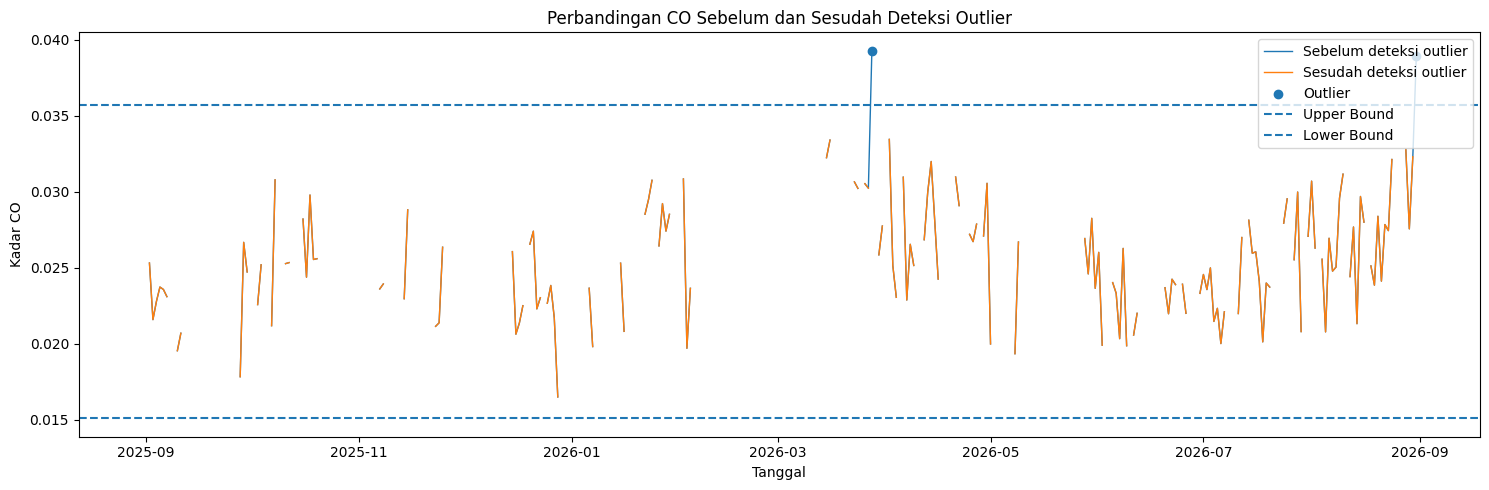

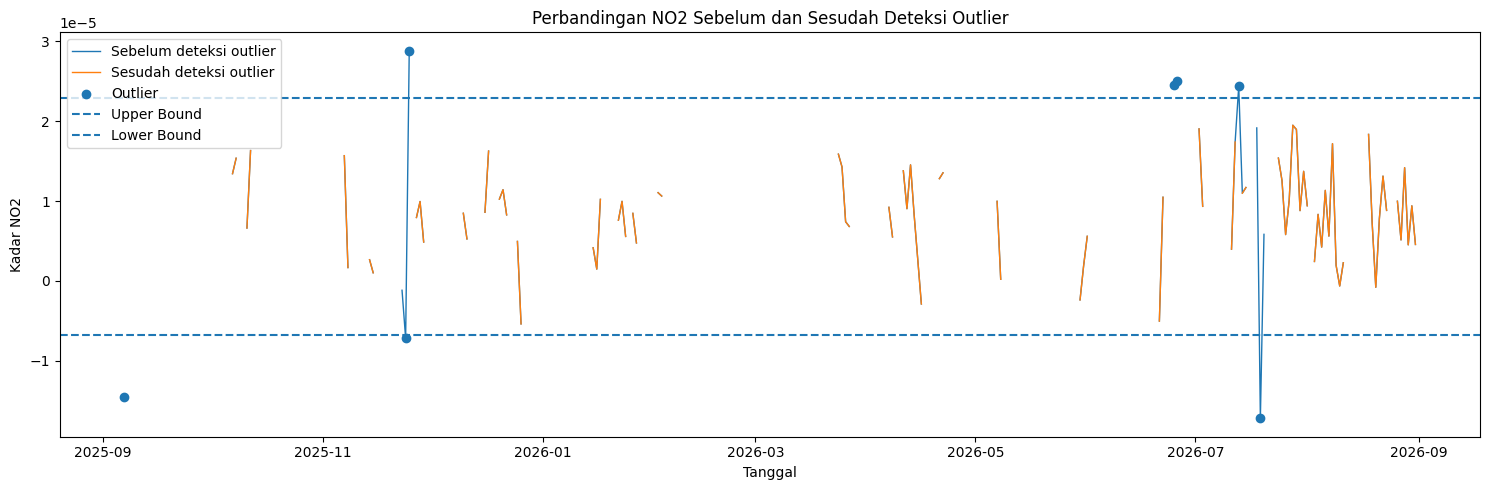

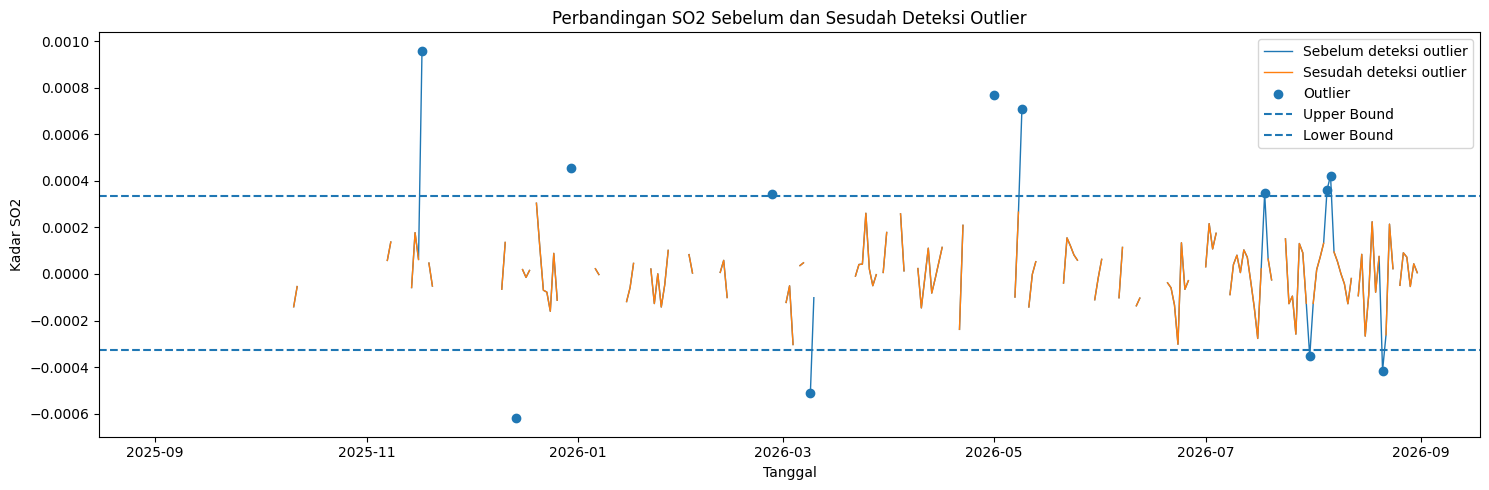

In [ ]:
# Perbandingan sebelum dan sesudah deteksi outlier

for pol in POLUTAN_TARGET:

    data_sebelum = df_awal.copy()
    data_sebelum[pol] = pd.to_numeric(data_sebelum[pol], errors="coerce")

    lower_bound = batas_iqr[pol]["lower"]
    upper_bound = batas_iqr[pol]["upper"]

    kondisi_outlier = (
        (data_sebelum[pol] < lower_bound) |
        (data_sebelum[pol] > upper_bound)
    )

    data_setelah = data_sebelum.copy()
    data_setelah.loc[kondisi_outlier, pol] = np.nan

    plt.figure(figsize=(15, 5))

    plt.plot(
        data_sebelum["date"],
        data_sebelum[pol],
        label="Sebelum deteksi outlier",
        linewidth=1
    )

    plt.plot(
        data_setelah["date"],
        data_setelah[pol],
        label="Sesudah deteksi outlier",
        linewidth=1
    )

    plt.scatter(
        data_sebelum.loc[kondisi_outlier, "date"],
        data_sebelum.loc[kondisi_outlier, pol],
        label="Outlier",
        marker="o"
    )

    plt.axhline(
        upper_bound,
        linestyle="dashed",
        label="Upper Bound"
    )

    plt.axhline(
        lower_bound,
        linestyle="dashed",
        label="Lower Bound"
    )

    plt.title(f"Perbandingan {pol} Sebelum dan Sesudah Deteksi Outlier")
    plt.xlabel("Tanggal")
    plt.ylabel(f"Kadar {pol}")
    plt.legend()
    plt.tight_layout()
    plt.show()

**Penjelasan kode:**
- perulangan dilakukan untuk CO, NO2, dan SO2 agar ketitidak polutan divisualisasikan dengan cara yang sama
- batas bawah dan atas IQR digunakan untuk menentukan data yang termasuk outlier
- grafik membandingkan kondisi sebelum dan sesudah outlier diubah mensehingga `NaN`


### 2.3 Visualisasi Data Sesudah Imputasi

Kode berikut untuk memvisualisasikan data setelah imputasi. Tanggal tetap menggunakan tanggal asli.


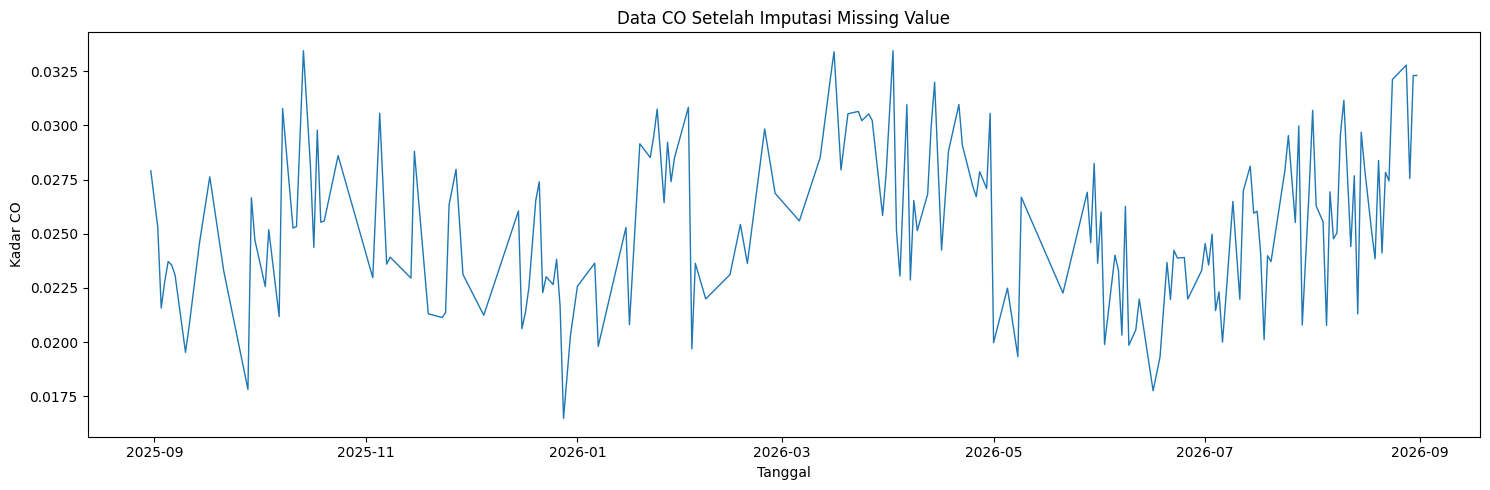

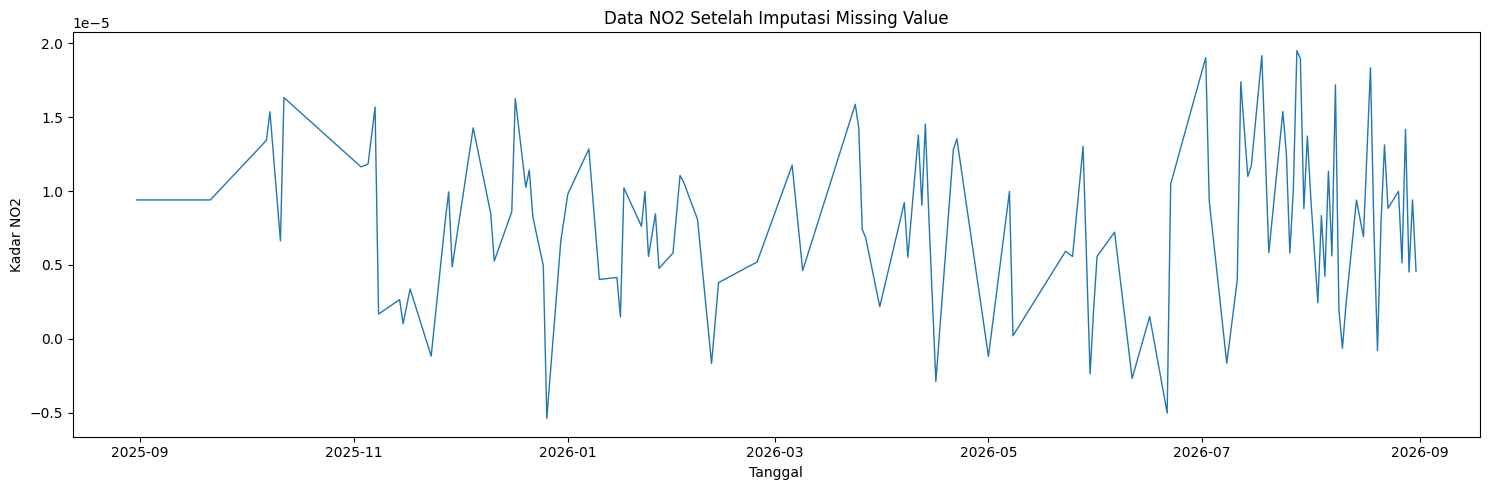

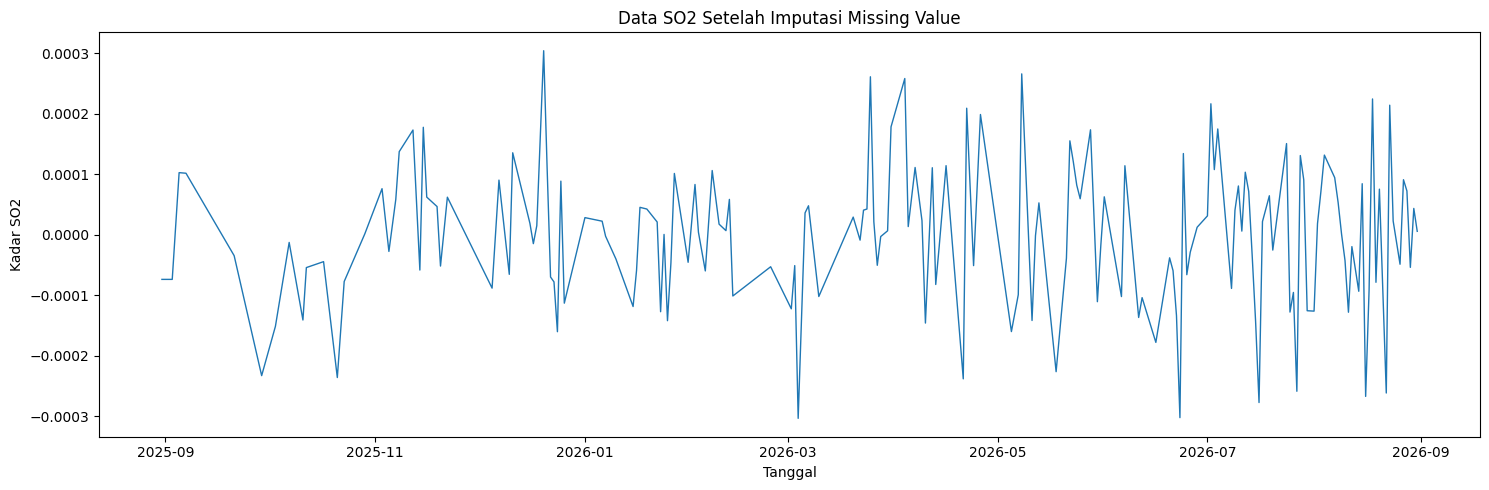

In [ ]:
for pol in POLUTAN_TARGET:

    data_sesudah = df_setelah.copy()
    data_sesudah[pol] = pd.to_numeric(data_sesudah[pol], errors="coerce")

    plt.figure(figsize=(15, 5))

    plt.plot(
        data_sesudah["date"],
        data_sesudah[pol],
        linewidth=1
    )

    plt.title(f"Data {pol} Setelah Imputasi Missing Value")
    plt.xlabel("Tanggal")
    plt.ylabel(f"Kadar {pol}")
    plt.tight_layout()
    plt.show()

**Penjelasan kode:**
- perulangan menampilkan data CO, NO2, dan SO2 setelah proses imputasi
- kolom `date` tetap menggunakan tanggal asli sehingtidak visualisasi tetap mengikuti urutan waktu


### 2.4 Perbandingan Missing Value

Tabel dan diagram berikut digunakan untuk membandingkan jumlah missing value pada data awal, setelah deteksi outlier, dan setelah imputasi. Tanggal pada dataset tetap dipertahankan.


,polutan,missing_awal,missing_setelah_outlier,missing_sesudah_imputasi
0,CO,180,182,0
1,NO2,240,247,0
2,SO2,181,193,0


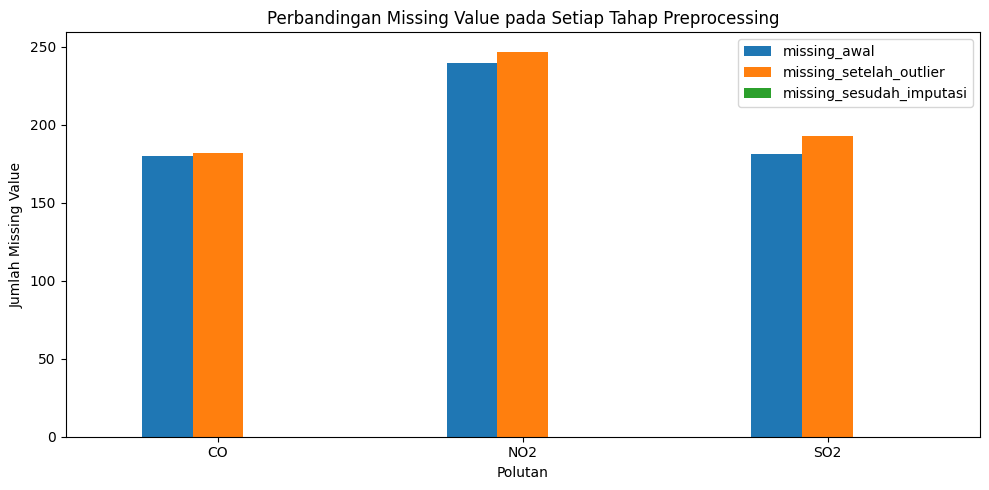

In [ ]:
kolom_tahap_missing = [
    "missing_awal",
    "missing_setelah_outlier",
    "missing_sesudah_imputasi"
]

tabel_missing = ringkasan_missing[["polutan"] + kolom_tahap_missing].copy()
display(tabel_missing)

tabel_missing_plot = tabel_missing.set_index("polutan")
tabel_missing_plot.plot(kind="bar", figsize=(10, 5))
plt.title("Perbandingan Missing Value pada Setiap Tahap Preprocessing")
plt.xlabel("Polutan")
plt.ylabel("Jumlah Missing Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Penjelasan kode:**
- `tabel_missing` mengmengambil jumlah missing value pada titidak tahap, yaitu sebelum preprocessing, setelah outlier diubah mensehingga `NaN`, dan setelah imputasi
- tabel ditampilkan agar perubahan jumlah missing value dapat dimelihat untuk CO, NO2, dan SO2
- data yang sama diuntuk mensehingga grafik batang agar penurunan missing value pada setiap tahap lebih mudah dibandingkan
- hasil akhir setelah imputasi digunakan sebagai `sinyal_bersih` untuk proses ekstraksi fitur


## 3. Ekstraksi Fitur

Sinyal yang sudah bersih dari `sinyal_bersih` diekstraksi memakai 68 fungsi fitur TSFEL yang sudah disepakati satu kelas. Ekstraksi dilakukan terpisah untuk tiap polutan, tapi memakai daftar fitur dan fungsi bantuan yang sama.

In [ ]:
import inspect

FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)

def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)

fs = 1
print(f"Jumlah fitur yang akan diekstraksi per polutan: {len(FEATURE_LIST)}")

Jumlah fitur yang akan diekstraksi per polutan: 68


**Penjelasan kode:**
- `FEATURE_LIST` memuat 68 nama fungsi fitur TSFEL yang disepakati digunakan satu kelas
- `to_scalar()` merapikan hasil tiap fungsi fitur mensehingga satu angka tunggal, karena beberapa fungsi TSFEL mengembalikan array atau dictionary, bukan angka langsung
- `extract_one()` memanggil fungsi fitur sesuai namanya, dan otomatis menyesuaikan apakah fungsi itu butuh parameter `fs` (sampling rate) atau tidak
- `fs = 1` menandakan sampling rate sinyal adalah 1 (satu observasi per hari)

### 3.1 Ekstraksi Fitur CO

In [ ]:
row_co = {}
for fn_name in FEATURE_LIST:
    row_co[fn_name] = extract_one(fn_name, sinyal_bersih["CO"], fs)

extracted_co = pd.DataFrame([row_co])
print(f"CO: {extracted_co.shape[1]} fitur berhasil diekstraksi")
extracted_co.to_csv('CO_Tikala_TSFEL.csv', index=False)

CO: 68 fitur berhasil diekstraksi


**Penjelasan kode:**
- perulangan `for` memanggil `extract_one()` untuk setiap nama fitur di `FEATURE_LIST`, memakai sinyal CO yang sudah bersih dari `sinyal_bersih["CO"]`
- hasilnya dikumpulkan dalam dictionary `row_co`, lalu diubah sehingga satu baris DataFrame `extracted_co` berisi 68 kolom
- baris terakhir menyimpan hasilnya sebagai `CO_Tikala_TSFEL.csv`

### 3.2 Ekstraksi Fitur NO2

In [ ]:
row_no2 = {}
for fn_name in FEATURE_LIST:
    row_no2[fn_name] = extract_one(fn_name, sinyal_bersih["NO2"], fs)

extracted_no2 = pd.DataFrame([row_no2])
print(f"NO2: {extracted_no2.shape[1]} fitur berhasil diekstraksi")
extracted_no2.to_csv('NO2_Tikala_TSFEL.csv', index=False)

NO2: 68 fitur berhasil diekstraksi


/usr/local/lib/python3.13/dist-packages/tsfel/feature_extraction/features_utils.py:534: RuntimeWarning: invalid value encountered in divide
  rs = np.divide(r, s)


**Penjelasan kode:**
- prosesnya sama persis dengan ekstraksi CO, bedanya sinyal yang digunakan dimengambil dari `sinyal_bersih["NO2"]`
- hasilnya disimpan terpisah sebagai `NO2_Tikala_TSFEL.csv`

### 3.3 Ekstraksi Fitur SO2

In [ ]:
row_so2 = {}
for fn_name in FEATURE_LIST:
    row_so2[fn_name] = extract_one(fn_name, sinyal_bersih["SO2"], fs)

extracted_so2 = pd.DataFrame([row_so2])
print(f"SO2: {extracted_so2.shape[1]} fitur berhasil diekstraksi")
extracted_so2.to_csv('SO2_Tikala_TSFEL.csv', index=False)

SO2: 68 fitur berhasil diekstraksi


/usr/local/lib/python3.13/dist-packages/tsfel/feature_extraction/features_utils.py:534: RuntimeWarning: invalid value encountered in divide
  rs = np.divide(r, s)


**Penjelasan kode:**
- pola kodenya identik dengan dua polutan sebelumnya, kali ini memakai `sinyal_bersih["SO2"]`
- hasilnya disimpan sebagai `SO2_Tikala_TSFEL.csv`, melengkapi titidak file hasil ekstraksi (CO, NO2, SO2)

## 4. Visualisasi dan Tabel Hasil Ekstraksi Fitur

Karena tiap polutan diekstraksi secara terpisah, hasilnya ditampilkan satu per satu dalam bentuk tabel vertikal (68 baris per polutan), lalu dibandingkan lewat grafik.

### 4.1 Tabel Hasil Ekstraksi CO

In [ ]:
tabel_co = extracted_co.T.reset_index()
tabel_co.columns = ["Fitur", "Nilai"]
tabel_co

,Fitur,Nilai
0,abs_energy,0.233753
1,auc,9.101386
2,autocorr,7.000000
3,average_power,0.000646
4,calc_centroid,185.419585
...,...,...
63,wavelet_energy,0.007593
64,wavelet_entropy,2.112171
65,wavelet_std,0.007422
66,wavelet_var,0.000064


**Penjelasan kode:**
- `.T` membalik posisi baris dan kolom, sehingtidak tiap fitur mensehingga satu baris tersecara manual, lebih mudah dibaca dibanding tabel 1 baris 68 kolom

### 4.2 Tabel Hasil Ekstraksi NO2

In [ ]:
tabel_no2 = extracted_no2.T.reset_index()
tabel_no2.columns = ["Fitur", "Nilai"]
tabel_no2

,Fitur,Nilai
0,abs_energy,3.100675e-08
1,auc,2.889237e-03
2,autocorr,5.000000e+00
3,average_power,8.565401e-11
4,calc_centroid,1.719391e+02
...,...,...
63,wavelet_energy,8.283682e-06
64,wavelet_entropy,2.121934e+00
65,wavelet_std,8.263201e-06
66,wavelet_var,7.518352e-11


**Penjelasan kode:**
- caranya sama seperti tabel CO, hanya sumber datanya diganti ke `extracted_no2`

### 4.3 Tabel Hasil Ekstraksi SO2

In [ ]:
tabel_so2 = extracted_so2.T.reset_index()
tabel_so2.columns = ["Fitur", "Nilai"]
tabel_so2

,Fitur,Nilai
0,abs_energy,3.801074e-06
1,auc,2.584833e-02
2,autocorr,2.000000e+00
3,average_power,1.050020e-08
4,calc_centroid,1.999815e+02
...,...,...
63,wavelet_energy,1.529690e-04
64,wavelet_entropy,2.150468e+00
65,wavelet_std,1.529661e-04
66,wavelet_var,2.499851e-08


**Penjelasan kode:**
- caranya sama seperti dua tabel sebelumnya, sumber datanya `extracted_so2`

### 4.4 Grafik Perbandingan Fitur Statistik Dasar Antarpolutan

Membandingkan beberapa fitur statistik dasar (`calc_mean`, `calc_std`, `skewness`, `kurtosis`) di antara CO, NO2, dan SO2, untuk memelihat perbedaan karakter sinyal tiap polutan setelah dibersihkan.

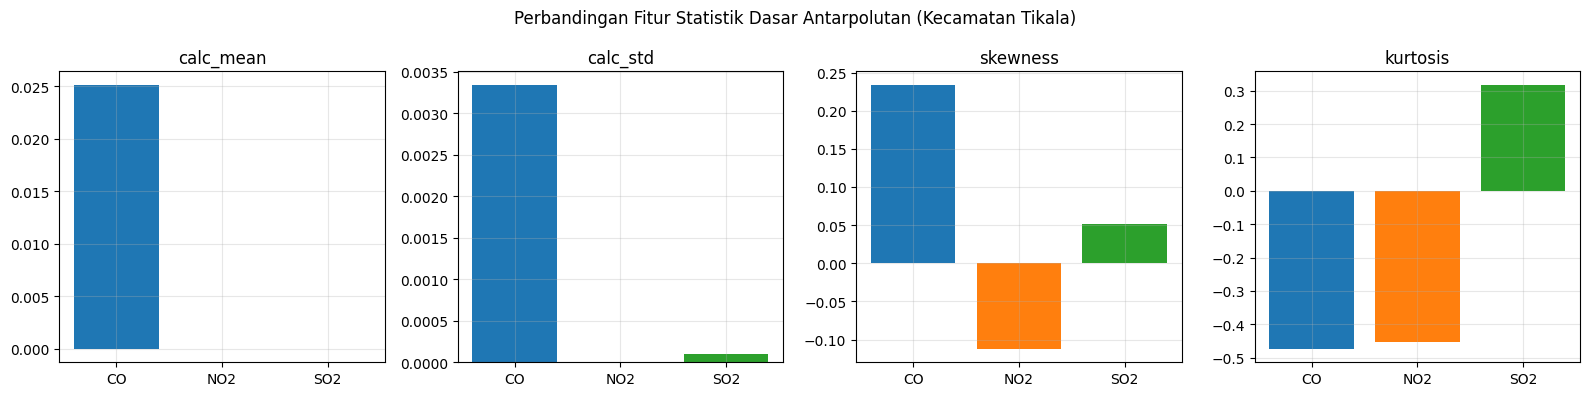

In [ ]:
import matplotlib.pyplot as plt

fitur_pembanding = ["calc_mean", "calc_std", "skewness", "kurtosis"]
data_polutan = {"CO": extracted_co, "NO2": extracted_no2, "SO2": extracted_so2}

fig, axes = plt.subplots(1, len(fitur_pembanding), figsize=(16, 4))

for ax, fitur in zip(axes, fitur_pembanding):
    nilai = [data_polutan[pol][fitur].values[0] for pol in data_polutan]
    ax.bar(list(data_polutan.keys()), nilai, color=["tab:blue", "tab:orange", "tab:green"])
    ax.set_title(fitur)
    ax.grid(alpha=0.3)

plt.suptitle("Perbandingan Fitur Statistik Dasar Antarpolutan (Kecamatan Tikala)")
plt.tight_layout()
plt.show()

**Penjelasan kode:**
- `data_polutan` mengumpulkan ketitidak DataFrame hasil ekstraksi dalam satu dictionary, agar mudah dipanggil di dalam perulangan
- tiap subplot menampilkan satu fitur pembanding dalam bentuk bar chart, dengan titidak batang mewakili CO, NO2, dan SO2

### 4.5 Grafik Seluruh 68 Fitur per Polutan

Menampilkan seluruh 68 nilai fitur untuk tiap polutan dalam satu grafik garis, agar pola umumnya termelihat tanpa perlu membuka tabel satu per satu.

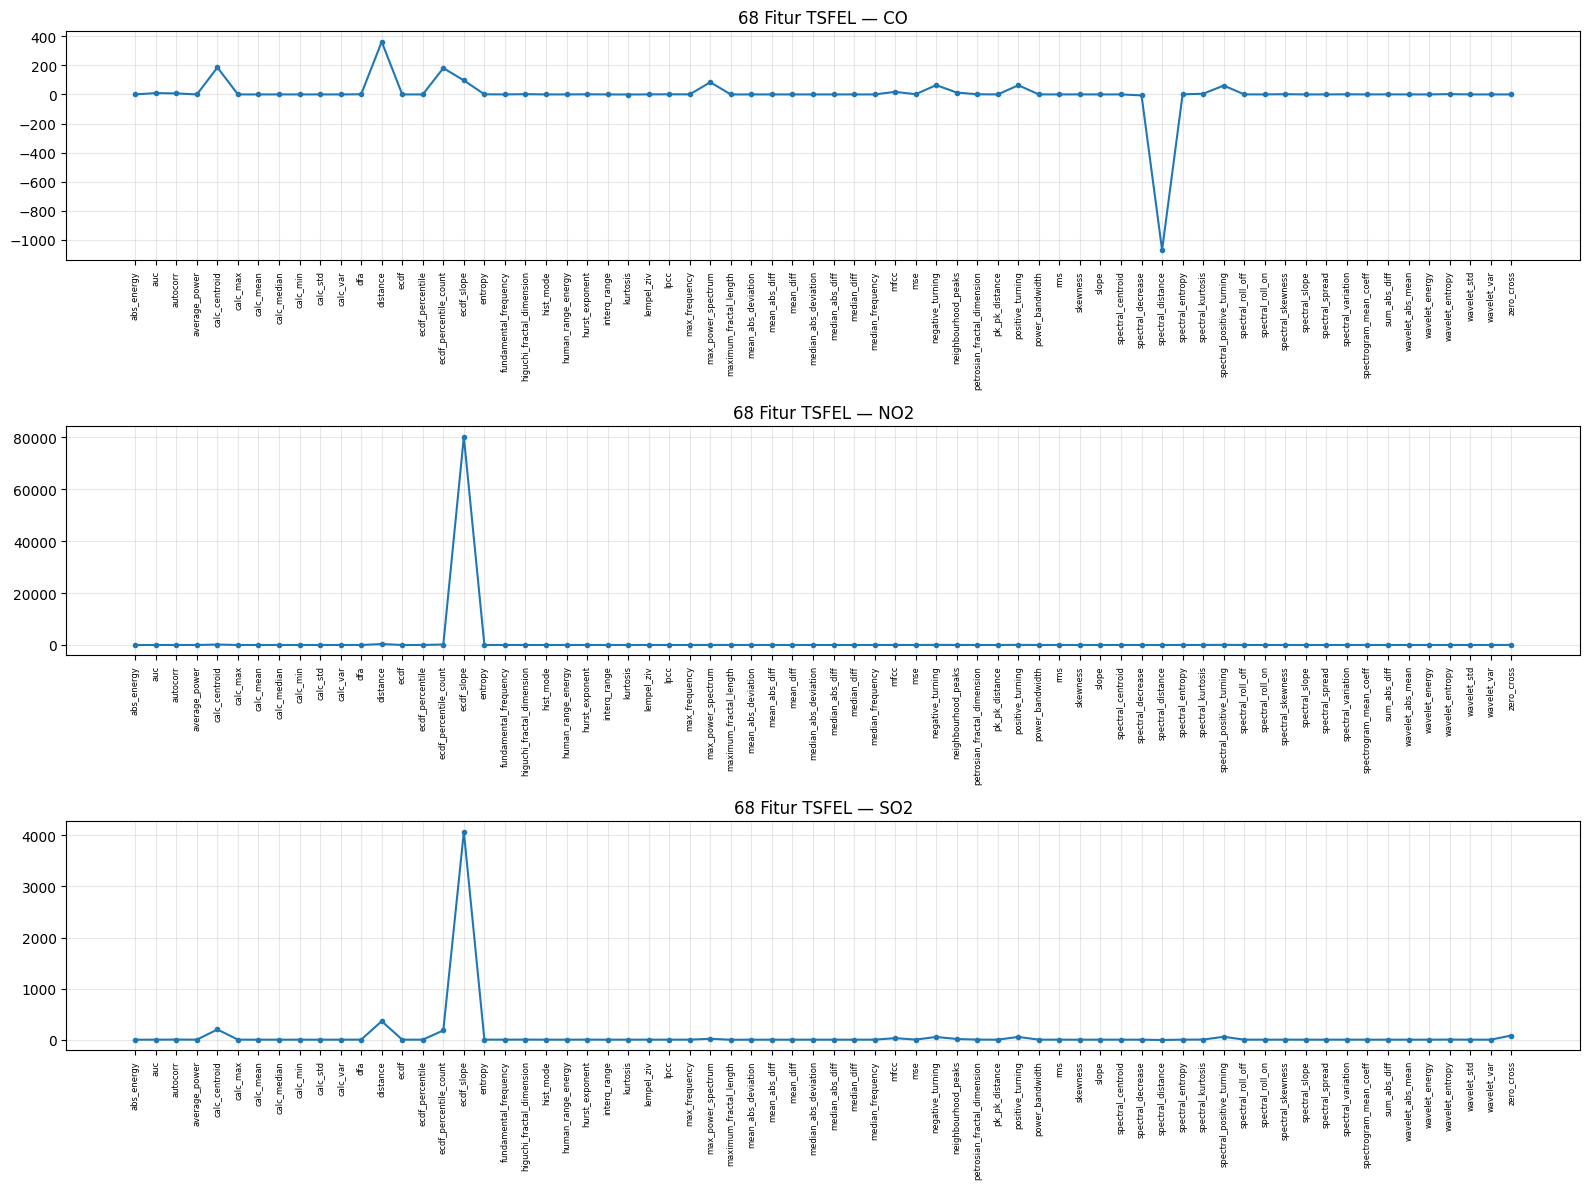

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

for ax, (pol, data) in zip(axes, data_polutan.items()):
    nilai_fitur = data.iloc[0].values
    nama_fitur = data.columns
    ax.plot(nama_fitur, nilai_fitur, marker="o", markersize=3, color="tab:blue")
    ax.set_title(f"68 Fitur TSFEL — {pol}")
    ax.tick_params(axis="x", rotation=90, labelsize=6)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("grafik_68_fitur_per_polutan.png", dpi=100)
plt.show()

**Penjelasan kode:**
- karena skala nilai antarfitur bisa jauh berbeda (misalnya `abs_energy` dibanding `skewness`), grafik ini lebih sesuai digunakan untuk memelihat pola relatif tiap polutan secara terpisah, bukan membandingkan langsung nilai absolut antarfitur
- gambar disimpan sebagai `grafik_68_fitur_per_polutan.png`, agar bisa dilampirkan ke laporan

## 5. Ringkasan

Notebook ini menghasilkan titidak file terpisah, `CO_Tikala_TSFEL.csv`, `NO2_Tikala_TSFEL.csv`, dan `SO2_Tikala_TSFEL.csv`, masing-masing berisi satu baris dengan 68 kolom fitur TSFEL dari data Kecamatan Tikala, Manado. Ketitidak file ini mensehingga hasil akhir yang siap digabungkan dengan hasil kecamatan lain lewat proses yang dikoordinasikan komting sekelas.